# Tutorial 06 — Multi-Period Optimization: Storage and Intertemporal Coupling

> **What changes when a decision today changes what is possible tomorrow?**

## Where we are

```text
ED → UC → DC-OPF → AC-OPF → SOCP → >> multi-period << → uncertainty
                                   → Benders → column generation → capstone
                                    ^
                                    YOU ARE HERE
```

## Learning objectives

1. Write the state-of-charge recursion and see why it **couples periods**;
2. model charge/discharge efficiency, SOC limits and boundary conditions;
3. explain why simultaneous charging and discharging is usually excluded for
   free, and when it is not;
4. measure what storage is actually worth — and when it is worth nothing;
5. see how the problem grows with the horizon, which motivates Tutorials
   08–09.

## The structural change

Until now, every period could have been solved independently. Storage breaks
that. One variable, $SOC_t$, appears in two consecutive constraints, and
suddenly the whole horizon is one problem.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

from psopt_course.config import fast_mode, scaled, set_seed
from psopt_course.networks import daily_profiles
from psopt_course.plotting import COLORS, use_course_style
from psopt_course.solvers import solve

use_course_style()
set_seed()
print(f"reduced (fast) configuration: {fast_mode()}")

reduced (fast) configuration: False


## 1. A day of demand and renewables

,demand,pv,wind,residual
min,67.48,0.00,2.33,25.72
mean,98.47,21.06,14.20,63.22
max,123.95,71.04,24.99,120.10


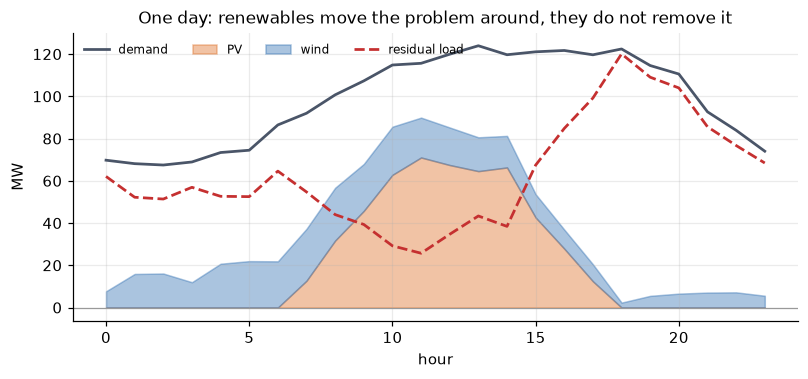

In [2]:
N_PERIODS = scaled(full=24, fast=12)
profiles = daily_profiles(n_periods=N_PERIODS)

PEAK_DEMAND = 150.0       # MW  -- sized so the expensive peaker is genuinely
                          #        needed, which is what gives storage a spread
                          #        to arbitrage. At 120 MW the cheap unit covers
                          #        almost everything and the battery is worthless.
PV_CAPACITY = 80.0        # MW
WIND_CAPACITY = 30.0      # MW

demand = profiles["demand"].to_numpy() * PEAK_DEMAND
pv = profiles["pv"].to_numpy() * PV_CAPACITY
wind = profiles["wind"].to_numpy() * WIND_CAPACITY
residual = demand - pv - wind

frame = pd.DataFrame(
    {"demand": demand, "pv": pv, "wind": wind, "residual": residual},
    index=profiles.index,
)
display(frame.describe().loc[["min", "mean", "max"]].round(2))

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(frame.index, frame["demand"], label="demand", color=COLORS["neutral"])
ax.fill_between(frame.index, 0, frame["pv"], alpha=0.4, color=COLORS["relaxed"], label="PV")
ax.fill_between(frame.index, frame["pv"], frame["pv"] + frame["wind"],
                alpha=0.4, color=COLORS["feasible"], label="wind")
ax.plot(frame.index, frame["residual"], "--", color=COLORS["infeasible"],
        label="residual load")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("hour")
ax.set_ylabel("MW")
ax.set_title("One day: renewables move the problem around, they do not remove it")
ax.legend(fontsize=8, ncol=4)
plt.show()

## 2. The storage equations

### State of charge

$$SOC_{t+1} = SOC_t + \Delta t\left(\eta_c\,P^{ch}_t - \frac{P^{dis}_t}{\eta_d}\right)$$

Read the efficiencies carefully, because the asymmetry is the whole economics:

* charging $P^{ch}$ puts only $\eta_c P^{ch}$ into the store — some is lost;
* discharging $P^{dis}$ **takes out** $P^{dis}/\eta_d$ — more than it delivers.

A round trip therefore returns $\eta_c\eta_d$ of what went in. At
$\eta_c = \eta_d = 0.95$ that is 90%, and the missing 10% is what the price
spread has to pay for.

### The rest

$$
\begin{aligned}
0 \le\ & SOC_t \le \overline{E} && \text{(energy capacity)} \\
0 \le\ & P^{ch}_t \le \overline{P} && \text{(charge rating)} \\
0 \le\ & P^{dis}_t \le \overline{P} && \text{(discharge rating)} \\
       & SOC_0 = SOC_{init},\quad SOC_T \ge SOC_{final} && \text{(boundary)}
\end{aligned}
$$

### Why the boundary condition is not optional

Without a terminal condition the optimizer will empty the store on the last
period — free energy, no consequence. That is an artefact of where you chose
to stop looking, not an operating strategy. Exercise 6.2 measures it.

### Simultaneous charge and discharge

Nothing above forbids $P^{ch}_t > 0$ *and* $P^{dis}_t > 0$ at the same time.
It is usually excluded for free: doing both wastes energy through
$\eta_c\eta_d < 1$, so any optimal solution avoids it whenever storage is not
being *paid* to burn energy. When that assumption fails — negative prices,
or a loss-minimising objective — you need a binary and the LP becomes a MILP.
Exercise 6.3 constructs the failure.

## 3. The model

In [3]:
def multiperiod_dispatch(
    demand, pv, wind, *,
    energy_capacity=200.0, power_rating=50.0,
    eta_charge=0.95, eta_discharge=0.95,
    soc_initial=0.5, soc_final=0.5,
    cyclic=False, terminal=True,
    no_simultaneous=False,
    curtailment_cost=5.0, thermal_cost=(40.0, 120.0), thermal_cap=(70.0, 90.0),
    dt=1.0,
):
    """Least-cost dispatch of two thermal units, renewables and one battery."""
    T = len(demand)
    m = pyo.ConcreteModel(name="multi-period dispatch")
    m.T = pyo.Set(initialize=range(T), ordered=True)

    m.p_base = pyo.Var(m.T, bounds=(0.0, thermal_cap[0]))
    m.p_peak = pyo.Var(m.T, bounds=(0.0, thermal_cap[1]))
    m.curtail = pyo.Var(m.T, bounds=(0.0, None))
    m.charge = pyo.Var(m.T, bounds=(0.0, power_rating))
    m.discharge = pyo.Var(m.T, bounds=(0.0, power_rating))
    m.soc = pyo.Var(m.T, bounds=(0.0, energy_capacity))

    if no_simultaneous:
        # Only needed when the objective can PAY storage to waste energy.
        m.mode = pyo.Var(m.T, domain=pyo.Binary)
        m.charge_mode = pyo.Constraint(
            m.T, rule=lambda m, t: m.charge[t] <= power_rating * m.mode[t])
        m.discharge_mode = pyo.Constraint(
            m.T, rule=lambda m, t: m.discharge[t] <= power_rating * (1 - m.mode[t]))

    @m.Constraint(m.T)
    def balance(m, t):
        renewable = pv[t] + wind[t] - m.curtail[t]
        return m.p_base[t] + m.p_peak[t] + renewable + m.discharge[t] - m.charge[t] == demand[t]

    @m.Constraint(m.T)
    def curtailment_limit(m, t):
        return m.curtail[t] <= pv[t] + wind[t]

    @m.Constraint(m.T)
    def soc_dynamics(m, t):
        """THE coupling constraint: period t is tied to period t-1."""
        inflow = dt * (eta_charge * m.charge[t] - m.discharge[t] / eta_discharge)
        if t == m.T.first():
            return m.soc[t] == soc_initial * energy_capacity + inflow
        return m.soc[t] == m.soc[m.T.prev(t)] + inflow

    if cyclic:
        m.cyclic = pyo.Constraint(
            expr=m.soc[m.T.last()] == soc_initial * energy_capacity)
    elif terminal:
        m.terminal = pyo.Constraint(
            expr=m.soc[m.T.last()] >= soc_final * energy_capacity)

    m.cost = pyo.Objective(
        expr=sum(
            thermal_cost[0] * m.p_base[t] + thermal_cost[1] * m.p_peak[t]
            + curtailment_cost * m.curtail[t]
            for t in m.T
        ),
        sense=pyo.minimize,
    )
    return m


model = multiperiod_dispatch(demand, pv, wind, cyclic=True)
record = solve(model, "LP", duals=True)
print(record.summary())

result = pd.DataFrame(
    {
        "demand": demand,
        "base": [pyo.value(model.p_base[t]) for t in model.T],
        "peak": [pyo.value(model.p_peak[t]) for t in model.T],
        "charge": [pyo.value(model.charge[t]) for t in model.T],
        "discharge": [pyo.value(model.discharge[t]) for t in model.T],
        "soc": [pyo.value(model.soc[t]) for t in model.T],
        "curtail": [pyo.value(model.curtail[t]) for t in model.T],
        "price": [model.dual[model.balance[t]] for t in model.T],
    },
    index=profiles.index,
)
display(result.round(2).head(8))

LP    via appsi_highs  optimal      obj=   68,547.0620   0.03s  144 vars (0 binary), 73 cons, gap=0.000%


,demand,base,peak,charge,discharge,soc,curtail,price
hour,,,,,,,,
0.0,69.76,62.08,0.0,0.0,0.0,100.0,0.0,40.0
1.0,68.12,52.22,0.0,0.0,0.0,100.0,0.0,40.0
2.0,67.48,51.38,0.0,0.0,0.0,100.0,0.0,40.0
3.0,68.92,56.93,0.0,0.0,0.0,100.0,0.0,40.0
4.0,73.40,52.66,0.0,0.0,0.0,100.0,0.0,40.0
5.0,74.48,52.51,0.0,0.0,0.0,100.0,0.0,40.0
6.0,86.46,64.59,0.0,0.0,0.0,100.0,0.0,40.0
7.0,91.99,54.73,0.0,0.0,0.0,100.0,0.0,40.0


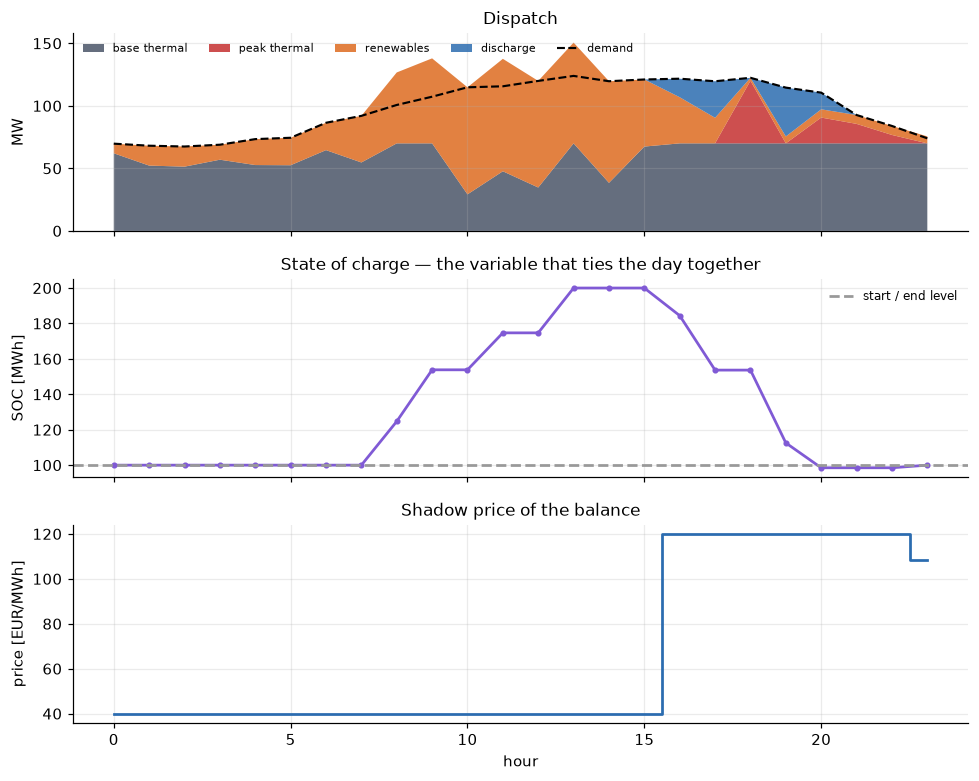

energy charged    :   106.83 MWh
energy discharged :    96.41 MWh
round-trip ratio  : 0.9025 (efficiency product = 0.9025)

simultaneous charge and discharge in any period: False
It was excluded without a binary, exactly as section 2 predicted.


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7.2), sharex=True)

axes[0].stackplot(
    result.index,
    result["base"], result["peak"], pv + wind - result["curtail"], result["discharge"],
    labels=["base thermal", "peak thermal", "renewables", "discharge"],
    colors=[COLORS["neutral"], COLORS["infeasible"], COLORS["relaxed"], COLORS["feasible"]],
    alpha=0.85,
)
axes[0].plot(result.index, result["demand"], "k--", lw=1.4, label="demand")
axes[0].set_ylabel("MW")
axes[0].set_title("Dispatch")
axes[0].legend(fontsize=7, ncol=5, loc="upper left")

axes[1].plot(result.index, result["soc"], "o-", ms=3, color=COLORS["accent"])
axes[1].axhline(0.5 * 200.0, ls="--", color="0.6", label="start / end level")
axes[1].set_ylabel("SOC [MWh]")
axes[1].set_title("State of charge — the variable that ties the day together")
axes[1].legend(fontsize=8)

axes[2].step(result.index, result["price"], where="mid", color=COLORS["feasible"])
axes[2].set_xlabel("hour")
axes[2].set_ylabel("price [EUR/MWh]")
axes[2].set_title("Shadow price of the balance")
fig.tight_layout()
plt.show()

charged = result["charge"].sum()
discharged = result["discharge"].sum()
print(f"energy charged    : {charged:8.2f} MWh")
print(f"energy discharged : {discharged:8.2f} MWh")
print(f"round-trip ratio  : {discharged / max(charged, 1e-9):.4f} "
      f"(efficiency product = {0.95 * 0.95:.4f})")
print(f"\nsimultaneous charge and discharge in any period: "
      f"{bool(((result['charge'] > 1e-6) & (result['discharge'] > 1e-6)).any())}")
print("It was excluded without a binary, exactly as section 2 predicted.")

## 4. Exercises

---

### Exercise 6.1 — What is the storage worth?

**Difficulty:** Basic

#### Your task

1. Solve with energy capacities from 0 to 400 MWh.
2. Record total cost, curtailment and the price spread.
3. Plot the value of storage, and find where it saturates.

#### Expected result

Cost should fall with capacity and then flatten — a battery can only arbitrage
the spread that exists. The marginal value of the *last* MWh should approach
zero.

#### Hint

`multiperiod_dispatch(..., energy_capacity=E, power_rating=E/4, cyclic=True)`
keeps a sensible 4-hour duration as capacity grows.

,cost [EUR],curtailment [MWh],price spread,saving vs no storage,marginal value [EUR/MWh]
capacity [MWh],,,,,
0.0,75843.245,0.0,80.000,0.000,NaN
100.0,72141.799,0.0,80.000,3701.446,37.014
200.0,68547.062,0.0,80.000,7296.183,35.947
300.0,64952.325,0.0,80.000,10890.920,35.947
400.0,61505.842,0.0,4.321,14337.403,34.465
600.0,61505.842,0.0,4.321,14337.403,0.000


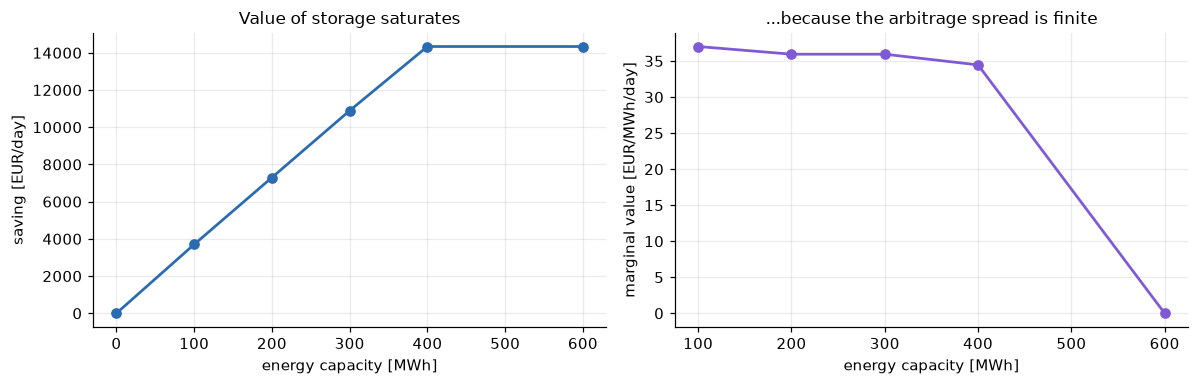

In [5]:
capacity_sweep = [0.0, 100.0, 200.0, 300.0, 400.0, 600.0]

rows = []
for capacity in capacity_sweep:
    m = multiperiod_dispatch(
        demand, pv, wind,
        energy_capacity=max(capacity, 1e-6),
        power_rating=max(capacity / 4.0, 1e-6),
        cyclic=True,
    )
    rec = solve(m, "LP", duals=True)
    prices = np.array([m.dual[m.balance[t]] for t in m.T])
    rows.append({
        "capacity [MWh]": capacity,
        "cost [EUR]": rec.objective,
        "curtailment [MWh]": sum(pyo.value(m.curtail[t]) for t in m.T),
        "price spread": prices.max() - prices.min(),
    })

storage_value = pd.DataFrame(rows).set_index("capacity [MWh]")
storage_value["saving vs no storage"] = (
    storage_value["cost [EUR]"].iloc[0] - storage_value["cost [EUR]"]
)
storage_value["marginal value [EUR/MWh]"] = (
    storage_value["saving vs no storage"].diff()
    / storage_value.index.to_series().diff()
)
display(storage_value.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(storage_value.index, storage_value["saving vs no storage"], "o-",
             color=COLORS["feasible"])
axes[0].set_xlabel("energy capacity [MWh]")
axes[0].set_ylabel("saving [EUR/day]")
axes[0].set_title("Value of storage saturates")
axes[1].plot(storage_value.index[1:], storage_value["marginal value [EUR/MWh]"].iloc[1:],
             "o-", color=COLORS["accent"])
axes[1].set_xlabel("energy capacity [MWh]")
axes[1].set_ylabel("marginal value [EUR/MWh/day]")
axes[1].set_title("...because the arbitrage spread is finite")
fig.tight_layout()
plt.show()

In [6]:
assert storage_value is not None, "build the `storage_value` DataFrame first"
assert (storage_value["cost [EUR]"].diff().dropna() <= 1e-6).all(), (
    "more storage cannot increase cost — it is an additional freedom"
)
assert (storage_value["saving vs no storage"] >= -1e-6).all()
print("Checks passed: cost is monotone in capacity.")

Checks passed: cost is monotone in capacity.


#### Interpretation

**Why does the value saturate?**

In [7]:
print("ANSWER.")
print()
print("A battery earns by moving energy from a cheap period to an expensive one.")
print("Its revenue per cycle is the PRICE SPREAD minus round-trip losses, and the")
print("spread is a property of the day, not of the battery.")
print()
print("Once the store is big enough to flatten the residual-load profile, extra")
print("capacity has nothing left to arbitrage: the cheap hours have already been")
print("filled and the expensive ones already served. The marginal value falls")
print("toward zero.")
print()
_m = storage_value["marginal value [EUR/MWh]"].dropna()
print(f"Measured here: the first {storage_value.index[1]:.0f} MWh were worth "
      f"{_m.iloc[0]:.2f} EUR/MWh/day,")
print(f"the last {storage_value.index[-1] - storage_value.index[-2]:.0f} MWh only "
      f"{_m.iloc[-1]:.2f}.")
print()
print("Notice the feedback: storage itself COMPRESSES the spread it lives on.")
print("Every MWh added makes the next one less valuable. That is why storage")
print("business cases are so sensitive to how much other storage gets built.")

ANSWER.

A battery earns by moving energy from a cheap period to an expensive one.
Its revenue per cycle is the PRICE SPREAD minus round-trip losses, and the
spread is a property of the day, not of the battery.

Once the store is big enough to flatten the residual-load profile, extra
capacity has nothing left to arbitrage: the cheap hours have already been
filled and the expensive ones already served. The marginal value falls
toward zero.

Measured here: the first 100 MWh were worth 37.01 EUR/MWh/day,
the last 200 MWh only 0.00.

Notice the feedback: storage itself COMPRESSES the spread it lives on.
Every MWh added makes the next one less valuable. That is why storage
business cases are so sensitive to how much other storage gets built.


---

### Exercise 6.2 — The horizon artefact

**Difficulty:** Intermediate

Drop the terminal condition and the optimizer will empty the store on the last
period, because after the horizon nothing exists.

#### Your task

1. Solve three ways: no terminal condition, a terminal floor, and cyclic.
2. Compare the cost and the final SOC.
3. Explain which number is misleading and why.

#### Expected result

The unconstrained version should look *cheapest* and end near empty. That
cheapness is fictitious.

,cost [EUR],final SOC [MWh],final SOC [%]
setting,,,
no terminal condition,57302.509,0.0,0.0
terminal floor (>= 50%),68547.062,100.0,50.0
cyclic (end = start),68547.062,100.0,50.0


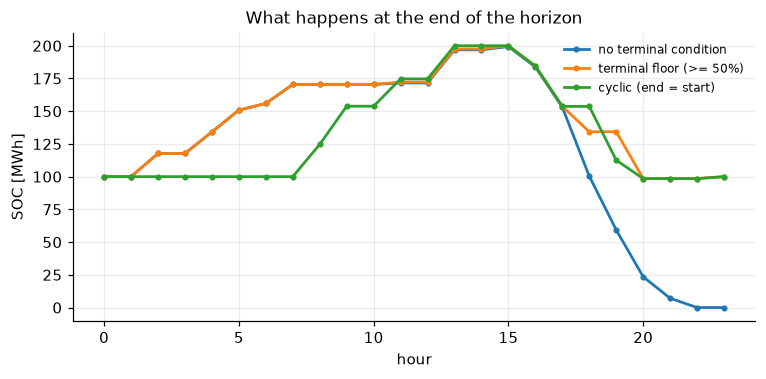


cheapest: no terminal condition at 57,302.51 EUR
its final SOC: 0.0%


In [8]:
settings = {
    "no terminal condition": {"terminal": False, "cyclic": False},
    "terminal floor (>= 50%)": {"terminal": True, "cyclic": False},
    "cyclic (end = start)": {"terminal": False, "cyclic": True},
}

rows = []
socs = {}
for label, kwargs in settings.items():
    m = multiperiod_dispatch(demand, pv, wind, **kwargs)
    rec = solve(m, "LP")
    trace = [pyo.value(m.soc[t]) for t in m.T]
    socs[label] = trace
    rows.append({
        "setting": label, "cost [EUR]": rec.objective,
        "final SOC [MWh]": trace[-1],
        "final SOC [%]": 100 * trace[-1] / 200.0,
    })

horizon_effect = pd.DataFrame(rows).set_index("setting")
display(horizon_effect.round(3))

fig, ax = plt.subplots(figsize=(8, 3.4))
for label, trace in socs.items():
    ax.plot(profiles.index, trace, "o-", ms=3, label=label)
ax.set_xlabel("hour")
ax.set_ylabel("SOC [MWh]")
ax.set_title("What happens at the end of the horizon")
ax.legend(fontsize=8)
plt.show()

cheapest = horizon_effect["cost [EUR]"].idxmin()
print(f"\ncheapest: {cheapest} at {horizon_effect.loc[cheapest, 'cost [EUR]']:,.2f} EUR")
print(f"its final SOC: {horizon_effect.loc[cheapest, 'final SOC [%]']:.1f}%")

In [9]:
assert horizon_effect is not None, "build the `horizon_effect` table first"
_free = horizon_effect.loc["no terminal condition"]
_cyc = horizon_effect.loc["cyclic (end = start)"]
assert _free["cost [EUR]"] <= _cyc["cost [EUR]"] + 1e-6, (
    "removing a constraint cannot increase cost"
)
assert _free["final SOC [MWh]"] <= _cyc["final SOC [MWh]"] + 1e-6, (
    "without a terminal condition the store should end lower"
)
print("Checks passed: the unconstrained run is cheaper and ends emptier.")

Checks passed: the unconstrained run is cheaper and ends emptier.


#### Interpretation

**Which cost is the honest one?**

In [10]:
print("ANSWER. Not the cheapest one.")
print()
print(f"The run with no terminal condition ends at "
      f"{_free['final SOC [%]']:.1f}% and looks")
print(f"{_cyc['cost [EUR]'] - _free['cost [EUR]']:,.2f} EUR cheaper. It achieved that by")
print("selling stored energy it never has to replace -- because the model stops")
print("at hour 24 and the consequences fall outside it.")
print()
print("This is a HORIZON ARTEFACT, and it is one of the most common errors in")
print("multi-period energy modelling. The optimizer is not cheating; it is")
print("answering the question asked, and the question was badly posed.")
print()
print("Three honest options:")
print("  1. CYCLIC: end where you started. Right for a representative day.")
print("  2. TERMINAL VALUE: price the leftover energy. Right when the horizon is")
print("     a genuine decision boundary, but you must justify the price.")
print("  3. ROLLING HORIZON: optimise 48 h, implement 24, re-solve. What")
print("     operations actually does, and it makes the artefact harmless because")
print("     the end is always far away.")
print()
print("Never option 4: report the unconstrained number without saying the store")
print("was drained.")

ANSWER. Not the cheapest one.

The run with no terminal condition ends at 0.0% and looks
11,244.55 EUR cheaper. It achieved that by
selling stored energy it never has to replace -- because the model stops
at hour 24 and the consequences fall outside it.

This is a HORIZON ARTEFACT, and it is one of the most common errors in
multi-period energy modelling. The optimizer is not cheating; it is
answering the question asked, and the question was badly posed.

Three honest options:
  1. CYCLIC: end where you started. Right for a representative day.
  2. TERMINAL VALUE: price the leftover energy. Right when the horizon is
     a genuine decision boundary, but you must justify the price.
  3. ROLLING HORIZON: optimise 48 h, implement 24, re-solve. What
     operations actually does, and it makes the artefact harmless because
     the end is always far away.

Never option 4: report the unconstrained number without saying the store
was drained.


---

### Exercise 6.3 — Make simultaneous charge/discharge appear

**Difficulty:** Advanced

The claim in section 2 was that the LP excludes simultaneous charging and
discharging *for free*, because it wastes energy. Break the claim.

#### Your task

1. Find an objective under which wasting energy is rewarded, so the LP
   relaxation prefers $P^{ch}, P^{dis} > 0$ simultaneously.
2. Show it happens.
3. Add the binary and show it stops.
4. Say what this costs in problem class.

#### Think before coding

When is burning energy profitable? (Hint: what if a price is negative, or the
objective *rewards* consumption?)

In [11]:
# Reward consumption: a strongly negative cost on charging is exactly what a
# negative market price looks like to a storage operator.
def waste_case(no_simultaneous):
    m = multiperiod_dispatch(
        demand, pv, wind, cyclic=True, no_simultaneous=no_simultaneous,
    )
    # Pay the battery to charge AND to discharge. Physically silly, and it is
    # precisely the structure a negative price creates.
    m.cost.deactivate()
    m.perverse = pyo.Objective(
        expr=sum(
            40.0 * m.p_base[t] + 120.0 * m.p_peak[t]
            - 30.0 * m.charge[t] - 30.0 * m.discharge[t]
            for t in m.T
        ),
        sense=pyo.minimize,
    )
    return m


rows = []
for label, binary in [("LP (no binary)", False), ("MILP (with binary)", True)]:
    m = waste_case(binary)
    rec = solve(m, "MILP" if binary else "LP")
    both = sum(
        1 for t in m.T
        if pyo.value(m.charge[t]) > 1e-6 and pyo.value(m.discharge[t]) > 1e-6
    )
    rows.append({
        "formulation": label, "class": rec.problem_class,
        "objective": rec.objective,
        "periods with BOTH": both,
        "binaries": rec.n_binary,
        "seconds": rec.seconds,
    })

simultaneous = pd.DataFrame(rows).set_index("formulation")
display(simultaneous.round(4))

,class,objective,periods with BOTH,binaries,seconds
formulation,,,,,
LP (no binary),LP,10391.0387,24,0,0.0181
MILP (with binary),MILP,47884.4146,0,24,0.6829


In [12]:
assert simultaneous is not None, "build the `simultaneous` table first"
assert simultaneous.loc["LP (no binary)", "periods with BOTH"] > 0, (
    "the perverse objective should make the LP charge and discharge at once"
)
assert simultaneous.loc["MILP (with binary)", "periods with BOTH"] == 0, (
    "the binary should forbid it"
)
assert simultaneous.loc["MILP (with binary)", "binaries"] > 0
print("Checks passed: the LP does it, the MILP does not.")

Checks passed: the LP does it, the MILP does not.


#### Interpretation

**When do you need the binary, and what does it cost?**

In [13]:
lp_row = simultaneous.loc["LP (no binary)"]
milp_row = simultaneous.loc["MILP (with binary)"]
print("ANSWER.")
print()
print(f"The LP charged and discharged simultaneously in "
      f"{lp_row['periods with BOTH']:.0f} of {N_PERIODS} periods.")
print("It is not confused: with a reward for both, the cheapest thing to do is")
print("run energy in a circle and collect twice. The round-trip loss that")
print("normally forbids this has become a feature.")
print()
print("So the binary is needed exactly when the objective can PAY storage to")
print("waste energy:")
print("  - negative electricity prices (common with high renewable output);")
print("  - loss-minimising or curtailment-minimising objectives;")
print("  - subsidy or tariff structures rewarding throughput;")
print("  - some reserve products paid on volume.")
print()
print("And when it is NOT needed, adding it is a real cost:")
print(f"  class     {lp_row['class']} -> {milp_row['class']}")
print(f"  binaries  {lp_row['binaries']:.0f} -> {milp_row['binaries']:.0f}")
print(f"  time      {lp_row['seconds']:.3f}s -> {milp_row['seconds']:.3f}s")
print()
print("One binary per period per battery. Over a year at hourly resolution with")
print("a fleet of batteries that is a serious MILP, and it is why practitioners")
print("check whether their objective can reward waste before reaching for it.")

ANSWER.

The LP charged and discharged simultaneously in 24 of 24 periods.
It is not confused: with a reward for both, the cheapest thing to do is
run energy in a circle and collect twice. The round-trip loss that
normally forbids this has become a feature.

So the binary is needed exactly when the objective can PAY storage to
waste energy:
  - negative electricity prices (common with high renewable output);
  - loss-minimising or curtailment-minimising objectives;
  - subsidy or tariff structures rewarding throughput;
  - some reserve products paid on volume.

And when it is NOT needed, adding it is a real cost:
  class     LP -> MILP
  binaries  0 -> 24
  time      0.018s -> 0.683s

One binary per period per battery. Over a year at hourly resolution with
a fleet of batteries that is a serious MILP, and it is why practitioners
check whether their objective can reward waste before reaching for it.


---

### Exercise 6.4 — How does the problem grow? (research-style)

**Difficulty:** Advanced

#### Your task

1. Solve for horizons from short to long.
2. Record variables, constraints and solve time.
3. Fit the growth and say what it implies for a year-long, network-constrained,
   multi-scenario model.

#### Expected result

Variables and constraints grow linearly in $T$. Solve time grows faster than
linearly but nowhere near exponentially — this is still an LP.

,variables,constraints,seconds,cost,vars per period
periods,,,,,
12,72,37,0.0152,31800.4059,6.0
24,144,73,0.0166,68547.0620,6.0
48,288,145,0.0247,146142.6667,6.0
96,576,289,0.0413,298534.7588,6.0


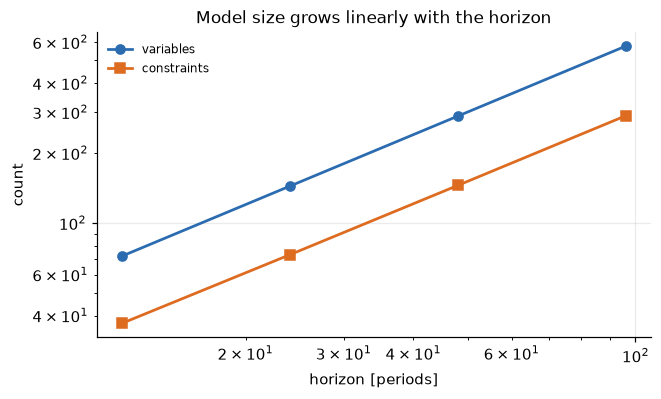


variables grow as T^1.00  (1.00 would be exactly linear)


In [14]:
horizons = [12, 24, 48, 96] if not fast_mode() else [8, 12, 24]

rows = []
for horizon in horizons:
    prof = daily_profiles(n_periods=horizon)
    d = prof["demand"].to_numpy() * PEAK_DEMAND
    s = prof["pv"].to_numpy() * PV_CAPACITY
    w = prof["wind"].to_numpy() * WIND_CAPACITY
    m = multiperiod_dispatch(d, s, w, cyclic=True)
    rec = solve(m, "LP")
    rows.append({
        "periods": horizon, "variables": rec.n_variables,
        "constraints": rec.n_constraints, "seconds": rec.seconds,
        "cost": rec.objective,
    })

scaling = pd.DataFrame(rows).set_index("periods")
scaling["vars per period"] = scaling["variables"] / scaling.index
display(scaling.round(4))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.loglog(scaling.index, scaling["variables"], "o-", label="variables",
          color=COLORS["feasible"])
ax.loglog(scaling.index, scaling["constraints"], "s-", label="constraints",
          color=COLORS["relaxed"])
ax.set_xlabel("horizon [periods]")
ax.set_ylabel("count")
ax.set_title("Model size grows linearly with the horizon")
ax.legend(fontsize=8)
plt.show()

growth = np.polyfit(np.log(scaling.index), np.log(scaling["variables"]), 1)[0]
print(f"\nvariables grow as T^{growth:.2f}  (1.00 would be exactly linear)")

In [15]:
assert scaling is not None, "build the `scaling` table first"
assert scaling["vars per period"].std() < 1.0, (
    "variables per period should be essentially constant"
)
assert (scaling["variables"].diff().dropna() > 0).all()
print("Checks passed: the model grows linearly in the horizon.")

Checks passed: the model grows linearly in the horizon.


#### Interpretation

**What does this imply for a realistic model?**

In [16]:
print("ANSWER.")
print()
print(f"Size grows as T^{growth:.2f} -- linear, as expected: each period adds a fixed")
print("number of variables and constraints. An LP of this shape stays tractable")
print("for a long time.")
print()
print("The trouble starts when the other dimensions multiply:")
print()
print("    periods  x  scenarios  x  contingencies  x  network buses")
print()
print("A year at hourly resolution (8760), 50 renewable scenarios and a few")
print("hundred buses is already tens of millions of variables -- and if")
print("commitment binaries are involved, it is a MILP of that size.")
print()
print("That product is what Tutorials 08 and 09 exist to break. Notice the")
print("STRUCTURE this model already has: fix the storage sizing and each")
print("scenario decouples; fix the commitment and each period nearly decouples.")
print("Those are exactly the structures Benders and column generation exploit.")
print()
print("The coupling constraint here -- soc_dynamics -- is also the obstacle. It")
print("is why you cannot simply solve 24 independent hourly problems, and")
print("recognising which constraints couple what is the first step in choosing a")
print("decomposition.")

ANSWER.

Size grows as T^1.00 -- linear, as expected: each period adds a fixed
number of variables and constraints. An LP of this shape stays tractable
for a long time.

The trouble starts when the other dimensions multiply:

    periods  x  scenarios  x  contingencies  x  network buses

A year at hourly resolution (8760), 50 renewable scenarios and a few
hundred buses is already tens of millions of variables -- and if
commitment binaries are involved, it is a MILP of that size.

That product is what Tutorials 08 and 09 exist to break. Notice the
STRUCTURE this model already has: fix the storage sizing and each
scenario decouples; fix the commitment and each period nearly decouples.
Those are exactly the structures Benders and column generation exploit.

The coupling constraint here -- soc_dynamics -- is also the obstacle. It
is why you cannot simply solve 24 independent hourly problems, and
recognising which constraints couple what is the first step in choosing a
decomposition.


## 5. Key takeaways

1. **One recursion couples the whole horizon.** $SOC_t$ appears in two
   consecutive constraints, and the periods stop being separable.
2. **Efficiency is asymmetric.** A round trip returns $\eta_c\eta_d$, and that
   loss is what sets the minimum arbitrage spread.
3. **Boundary conditions are modelling decisions, not formalities.** Omit the
   terminal condition and the model drains the store for free.
4. **Storage value saturates**, because it compresses the spread it lives on.
5. **Simultaneous charge/discharge is excluded for free — until the objective
   rewards waste.** Then you need a binary, and an LP becomes a MILP.
6. **Size grows linearly in the horizon** but multiplicatively across
   dimensions, which is what motivates decomposition.

## Further reading

- Morales, Conejo, Madsen, Pinson & Zugno, *Integrating Renewables in
  Electricity Markets*, Springer 2014.
- Sioshansi, Denholm, Jenkin & Weiss, "Estimating the value of electricity
  storage in PJM", *Energy Economics* 31(2), 2009.
- Pozo, "Convex hull formulations for linear modeling of energy storage
  systems", *IEEE Trans. Power Syst.* 38(6), 2023 — when the binary is and is
  not needed.

## Next

Tutorial 07 makes the future uncertain. "Feasible" stops being a yes/no
property and becomes a probability.